# 07 — Dimensionality Reduction
**Referencias:** ESL Cap. 14.5 (PCA) · Géron Cap. 8

## La maldición de la dimensionalidad (ESL 2.5)
En alta dimensión:
- Los puntos se vuelven **equidistantes** → kNN pierde poder
- El volumen de datos necesario crece **exponencialmente**
- La mayoría de las variables son **ruido o colineales**

PCA encuentra las direcciones de **máxima varianza** proyectando a un subespacio de menor dimensión.

In [7]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA, IncrementalPCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima'
})
np.random.seed(42)

# Dataset de alto valor: usuarios con 20 features
n = 1000
X_raw, y = make_classification(
    n_samples=n, n_features=20, n_informative=8, n_redundant=6,
    n_clusters_per_class=2, random_state=42
)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f'Dataset: {X.shape[0]} muestras × {X.shape[1]} features')

Dataset: 1000 muestras × 20 features


## 1 — PCA: varianza explicada y scree plot (ESL 14.5)

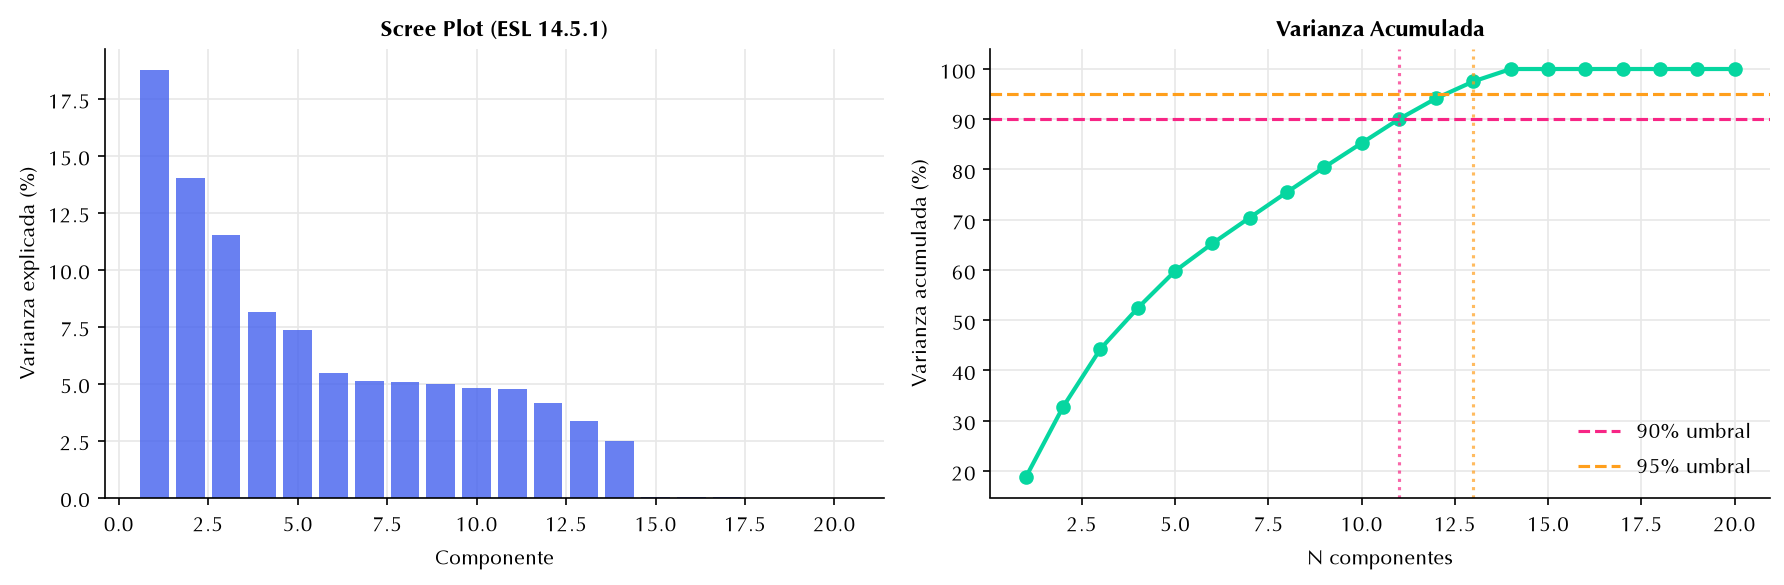

Para 90% varianza: 11 componentes (de 20)
Para 95% varianza: 13 componentes


In [13]:
pca_full = PCA().fit(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# Scree plot
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_ * 100,
            color='#4361ee', alpha=0.8)
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree Plot (ESL 14.5.1)')

# Varianza acumulada
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, 21), cumvar, 'o-', color='#06d6a0', linewidth=2)
axes[1].axhline(90, color='#f72585', linestyle='--', label='90% umbral')
axes[1].axhline(95, color='#ff9f1c', linestyle='--', label='95% umbral')
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
axes[1].axvline(n_90, color='#f72585', linestyle=':', alpha=0.7)
axes[1].axvline(n_95, color='#ff9f1c', linestyle=':', alpha=0.7)
axes[1].set_xlabel('N componentes'); axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza Acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Para 90% varianza: {n_90} componentes (de {X.shape[1]})')
print(f'Para 95% varianza: {n_95} componentes')

## 2 — Biplot: variables y observaciones en el mismo espacio (ESL 14.5.1)

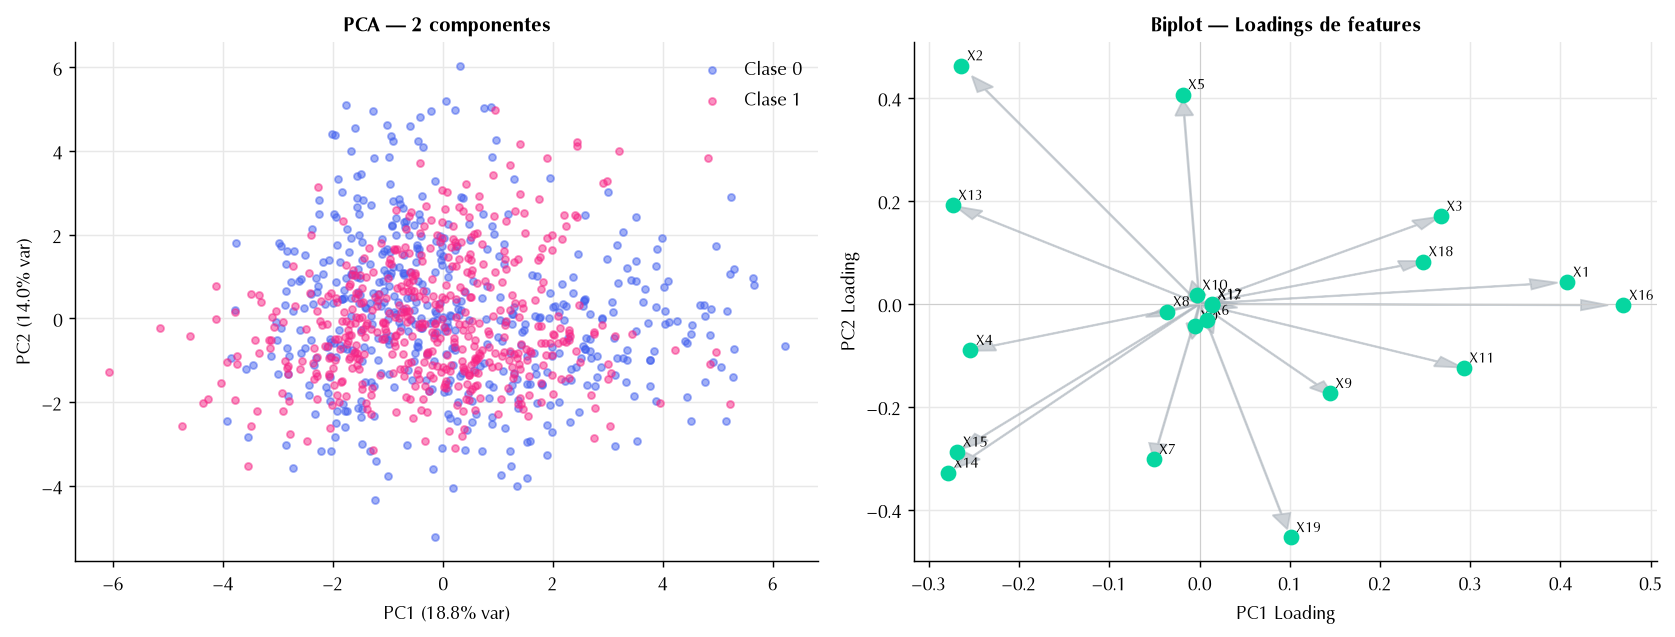

In [9]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter de observaciones coloreado por clase
for cls in [0, 1]:
    mask = y == cls
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], s=15, alpha=0.5,
                    color=['#4361ee','#f72585'][cls], label=f'Clase {cls}')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)')
axes[0].set_title('PCA — 2 componentes')
axes[0].legend()

# Loadings: contribución de cada feature a los PCs
loadings = pd.DataFrame(
    pca2.components_.T,
    columns=['PC1','PC2'],
    index=[f'X{i}' for i in range(X.shape[1])]
)

axes[1].scatter(loadings['PC1'], loadings['PC2'], s=60, color='#06d6a0', zorder=5)
for feat, row in loadings.iterrows():
    axes[1].annotate(feat, (row['PC1'], row['PC2']),
                     fontsize=8, xytext=(3, 3), textcoords='offset points')
    axes[1].arrow(0, 0, row['PC1']*0.9, row['PC2']*0.9,
                  head_width=0.02, color='#adb5bd', alpha=0.6)
axes[1].axhline(0, color='#ccc', linewidth=0.5); axes[1].axvline(0, color='#ccc', linewidth=0.5)
axes[1].set_xlabel('PC1 Loading'); axes[1].set_ylabel('PC2 Loading')
axes[1].set_title('Biplot — Loadings de features')

plt.tight_layout()
plt.show()

## 3 — Kernel PCA: no linealidad (Géron Cap. 8)
Kernel PCA aplica el kernel trick para encontrar componentes en un espacio de features de alta dimensión.

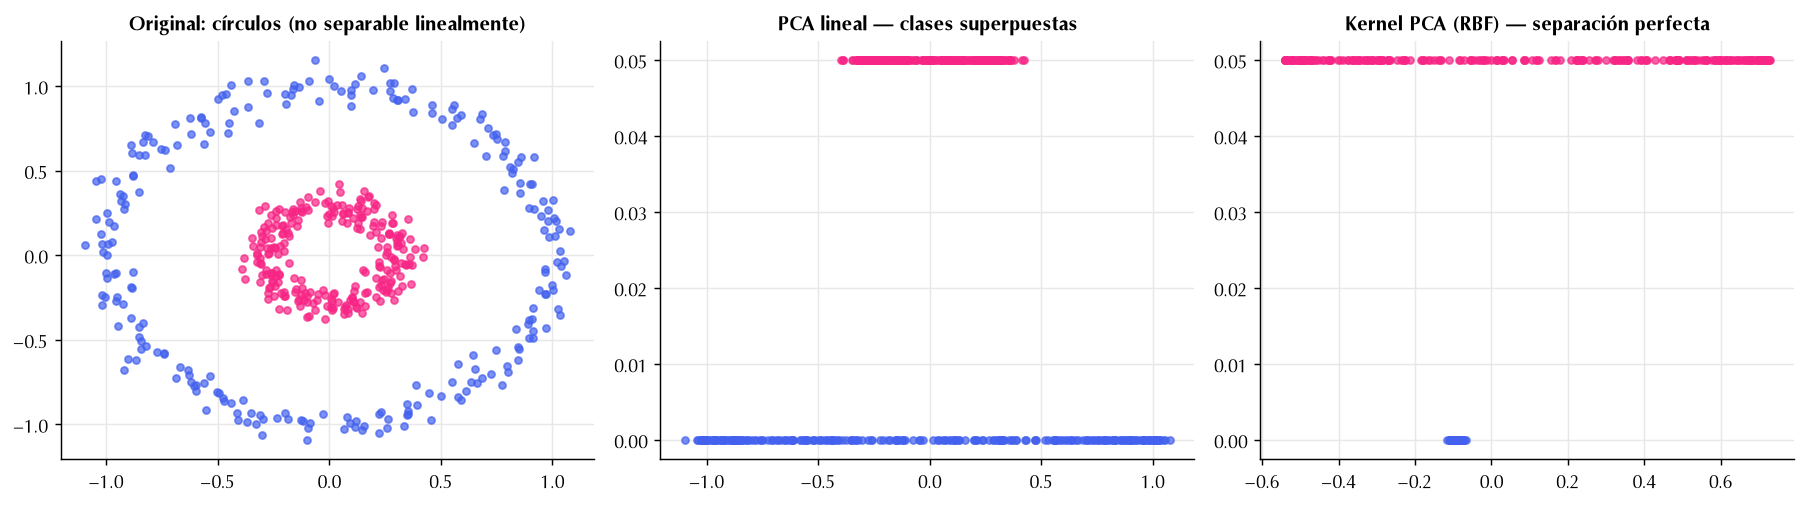

In [10]:
from sklearn.datasets import make_circles
X_circles, y_circles = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Datos originales
for cls in [0, 1]:
    mask = y_circles == cls
    axes[0].scatter(X_circles[mask,0], X_circles[mask,1], s=15, alpha=0.7,
                    color=['#4361ee','#f72585'][cls])
axes[0].set_title('Original: círculos (no separable linealmente)')

# PCA lineal: no separa
X_pca_linear = PCA(n_components=1).fit_transform(X_circles)
for cls in [0, 1]:
    mask = y_circles == cls
    axes[1].scatter(X_pca_linear[mask,0], np.zeros(mask.sum()) + cls*0.05,
                    s=15, alpha=0.7, color=['#4361ee','#f72585'][cls])
axes[1].set_title('PCA lineal — clases superpuestas')

# Kernel PCA con RBF
kpca = KernelPCA(n_components=1, kernel='rbf', gamma=10)
X_kpca = kpca.fit_transform(X_circles)
for cls in [0, 1]:
    mask = y_circles == cls
    axes[2].scatter(X_kpca[mask,0], np.zeros(mask.sum()) + cls*0.05,
                    s=15, alpha=0.7, color=['#4361ee','#f72585'][cls])
axes[2].set_title('Kernel PCA (RBF) — separación perfecta')

plt.tight_layout()
plt.show()

## 4 — Incremental PCA: para datasets que no caben en RAM (Géron Cap. 8)

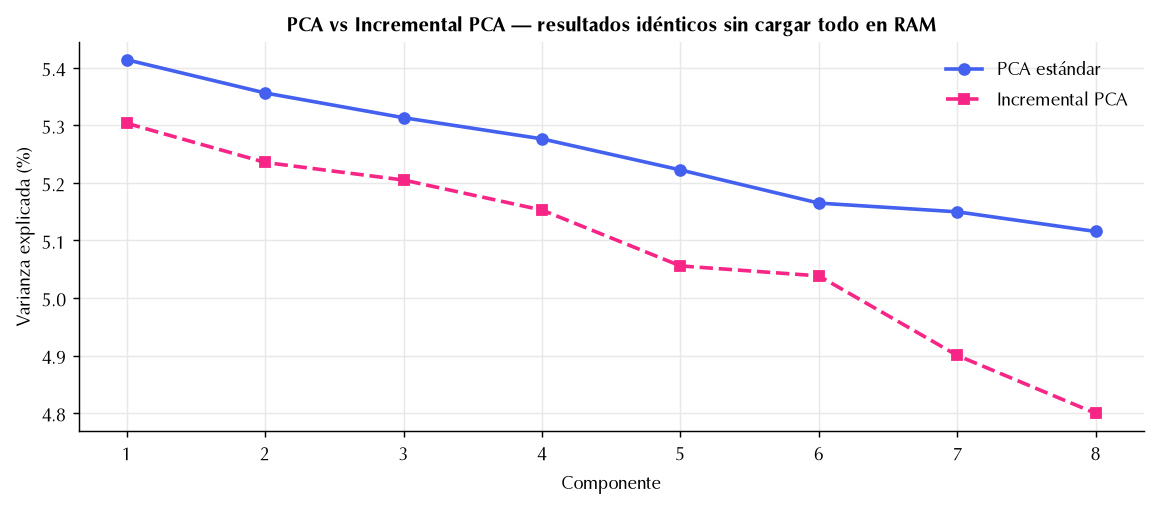

Diferencia max en varianza explicada: 3.16e-03


In [11]:
# Simular dataset grande procesado en batches
n_big = 10_000
X_big = np.random.randn(n_big, 20)

# Incremental PCA: no carga todo en memoria
n_batches = 10
batch_size = n_big // n_batches

ipca = IncrementalPCA(n_components=8)
for i in range(n_batches):
    batch = X_big[i*batch_size:(i+1)*batch_size]
    ipca.partial_fit(batch)

# Transformar (también en batches si fuera necesario)
X_ipca = ipca.transform(X_big)

# Comparar con PCA estándar
pca_std = PCA(n_components=8).fit(X_big)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1,9), pca_std.explained_variance_ratio_*100, 'o-', color='#4361ee', label='PCA estándar', linewidth=2)
ax.plot(range(1,9), ipca.explained_variance_ratio_*100, 's--', color='#f72585', label='Incremental PCA', linewidth=2)
ax.set_xlabel('Componente'); ax.set_ylabel('Varianza explicada (%)')
ax.set_title('PCA vs Incremental PCA — resultados idénticos sin cargar todo en RAM')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Diferencia max en varianza explicada: {np.abs(pca_std.explained_variance_ratio_ - ipca.explained_variance_ratio_).max():.2e}')

## 5 — t-SNE: visualización de alta dimensión (Géron Cap. 8)
t-SNE preserva la estructura **local** (vecinos) no la global. Solo para visualización.

In [12]:
# Reducir a 50 con PCA antes de t-SNE (práctica recomendada)
X_pca50 = PCA(n_components=10).fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for cls in [0, 1]:
    mask = y == cls
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], s=12, alpha=0.5,
                    color=['#4361ee','#f72585'][cls], label=f'Clase {cls}')
axes[0].set_title('PCA (2 componentes)')
axes[0].legend()

for cls in [0, 1]:
    mask = y == cls
    axes[1].scatter(X_tsne[mask,0], X_tsne[mask,1], s=12, alpha=0.5,
                    color=['#4361ee','#f72585'][cls], label=f'Clase {cls}')
axes[1].set_title('t-SNE (perplexity=30) — estructura local más clara')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Cuidado: t-SNE no preserva distancias globales — no usar para análisis cuantitativo')

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 6 — Feature Selection con SelectFromModel (Géron Cap. 4)

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Lasso: coeficientes → 0 para features irrelevantes
lasso = LassoCV(cv=5, random_state=42)
sfm_lasso = SelectFromModel(lasso)
sfm_lasso.fit(X, y)
X_lasso = sfm_lasso.transform(X)

# Random Forest importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
sfm_rf = SelectFromModel(rf, threshold='mean')
sfm_rf.fit(X, y)
X_rf = sfm_rf.transform(X)

# SelectKBest (univariado)
skb = SelectKBest(f_classif, k=8)
X_kbest = skb.fit_transform(X, y)

# Comparar features seleccionadas
feat_names = [f'X{i}' for i in range(X.shape[1])]

lasso_selected = np.array(feat_names)[sfm_lasso.get_support()]
rf_selected    = np.array(feat_names)[sfm_rf.get_support()]
kbest_selected = np.array(feat_names)[skb.get_support()]

fig, ax = plt.subplots(figsize=(10, 4))
methods_fs = ['Lasso', 'RF importance', 'SelectKBest']
n_selected = [len(lasso_selected), len(rf_selected), len(kbest_selected)]
colors = ['#4361ee','#f72585','#06d6a0']
bars = ax.bar(methods_fs, n_selected, color=colors)
for bar, n in zip(bars, n_selected):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(n),
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Features seleccionadas'); ax.set_ylim(0, X.shape[1])
ax.axhline(X.shape[1], color='#aaa', linestyle=':', label='Total features')
ax.set_title('Feature Selection — comparación de métodos')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Lasso:      {list(lasso_selected)}')
print(f'RF:         {list(rf_selected)}')
print(f'SelectKBest:{list(kbest_selected)}')

## Resumen

| Técnica | Cuándo usarla | Referencia |
|---|---|---|
| PCA estándar | Reducción general, features numéricas correlacionadas | ESL 14.5 |
| Kernel PCA | Datos con estructura no lineal | Géron Cap. 8 |
| Incremental PCA | Dataset no cabe en RAM, streaming | Géron Cap. 8 |
| t-SNE | **Solo visualización** de alta dimensión | Géron Cap. 8 |
| SelectFromModel | Feature selection basada en modelo | Géron Cap. 4 |
| SelectKBest | Prueba univariada rápida como baseline | Géron Cap. 4 |

**Siguiente:** `08_pipelines.ipynb`